In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import argparse
from pathlib import Path
from collections import defaultdict
from dataclasses import dataclass
from zipfile import ZipFile

from tqdm.auto import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from config.default import cfg
from lib.datasets.datamodules import DataModule
from lib.models.builder import build_model
from lib.utils.data import data_to_model_device
from transforms3d.quaternions import mat2quat

from lib.models.rscr.model import project_3dto2d

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
def norm_scr(x, min, max):
    print(x.min(axis=(0,1)), x.max(axis=(0,1)))
    return (x - min) / (max - min)

In [11]:
class Args():
    def __init__(self):
        self.cfg_path = 'config/rscregrssion/rscr_dev.yaml'
        self.dataset_cfg_path = 'config/sevenscenes_viz.yaml'
        self.checkpoint = 'weights/(7s_hard)hybrid_from_pretrained/version_2/checkpoints/last.ckpt'
        # self.checkpoint = ''
        self.split = 'val'
        self.output_root = Path('dev_outputs/')
args = Args()

cfg.merge_from_file(args.dataset_cfg_path)
cfg.merge_from_file(args.cfg_path)

In [12]:
# Create dataloader
if args.split == 'test':
    dataloader = DataModule(cfg).test_dataloader()
elif args.split == 'val':
    cfg.TRAINING.BATCH_SIZE = 1
    cfg.TRAINING.NUM_WORKERS = 1
    dataloader = DataModule(cfg).val_dataloader()
else:
    raise NotImplemented(f'Invalid split: {args.split}')

In [13]:
# Create model
model = build_model(cfg, args.checkpoint)

In [14]:
def plot_img(img, title, cmap='jet', axis='off', colorbar=True):
    im = plt.imshow(img, cmap=cmap)
    if colorbar:
        plt.colorbar(im, fraction=0.046, pad=0.04, orientation='horizontal')
    plt.title(title)
    plt.axis(axis)

In [19]:
# Get predictions from model
# results_dict = predict(dataloader, model)
loader, model = dataloader, model

# def predict(loader, model):
results_dict = defaultdict(list)

data = None
for i, data in tqdm(enumerate(loader)):
    if i == 3:
        break 

data = data_to_model_device(data, model)

T_gt_0to1 = data['T_0to1'].detach().cpu().numpy()[0]
T_gt_1to0 = np.linalg.inv(T_gt_0to1)
K0 = data['K_color0'].detach().cpu().numpy()[0]
K1 = data['K_color1'].detach().cpu().numpy()[0]
img0 = data['image0'].detach().cpu().numpy()[0].transpose(1,2,0)
img1 = data['image1'].detach().cpu().numpy()[0].transpose(1,2,0)
dep0 = data['depth0'].detach().cpu().numpy().transpose(1,2,0)
dep1 = data['depth1'].detach().cpu().numpy().transpose(1,2,0)

with torch.no_grad():
    R, t, n_inliers = model.forward_pose(data)
    out_dict = model.get_transformation_dict(data, 
        return_xyz1_1_B3HW=True, 
        return_uv1_1_B2HW=True)
    xyz1_0_B3HW = out_dict['xyz1_0_B3HW']
    uv1_1_B2HW = out_dict['uv1_1_B2HW']

R = R.detach().cpu().numpy()[0]
t = t.reshape(-1).detach().cpu().numpy()
xyz1_0_HW3 = xyz1_0_B3HW.detach().cpu().numpy()[0].transpose(1,2,0)
uv1_1_HW2 = uv1_1_B2HW.detach().cpu().numpy()[0].transpose(1,2,0)


0it [00:00, ?it/s]

In [20]:
# UV grid ground truth
H, W, _ = dep0.shape
gt_uv_hw2 = np.meshgrid(np.arange(W), np.arange(H))
gt_uv_hw2 = np.stack(gt_uv_hw2, axis=-1)
gt_uv_hw3 = np.concatenate([gt_uv_hw2, np.ones_like(gt_uv_hw2[..., :1])], axis=-1)
gt_uv_n3 = gt_uv_hw3.reshape(-1, 3)
print(gt_uv_hw3.shape)

# RSC ground truth
gt_xyz1_1_n3 = dep1.reshape(-1, 1) * (gt_uv_n3 @ np.linalg.inv(K1).T)
gt_xyz1_1_hw3 = gt_xyz1_1_n3.reshape(H, W, 3)

gt_xyz1_0_n3 = gt_xyz1_1_n3 @ T_gt_1to0[:3, :3].T + T_gt_1to0[:3, 3:4].T
gt_xyz1_0_hw3 = gt_xyz1_0_n3.reshape(H, W, 3)

# reprojection ground truth
gt_xyz1_1_n3 = (T_gt_0to1[:3, :3] @ gt_xyz1_0_n3.T + T_gt_0to1[:3, 3:4]).T
gt_xyz1_1_hw3 = gt_xyz1_1_n3.reshape(H, W, 3)

gt_uv1_1_n3 = (K1 @ gt_xyz1_1_n3.T).T
gt_uv1_1_n3 = gt_xyz1_1_n3 / gt_xyz1_1_n3[..., 2:]
gt_uv1_1_n2 = gt_uv1_1_n3[..., :2]
gt_uv1_1_hw2 = gt_uv1_1_n2.reshape(H, W, 2)

(480, 640, 3)


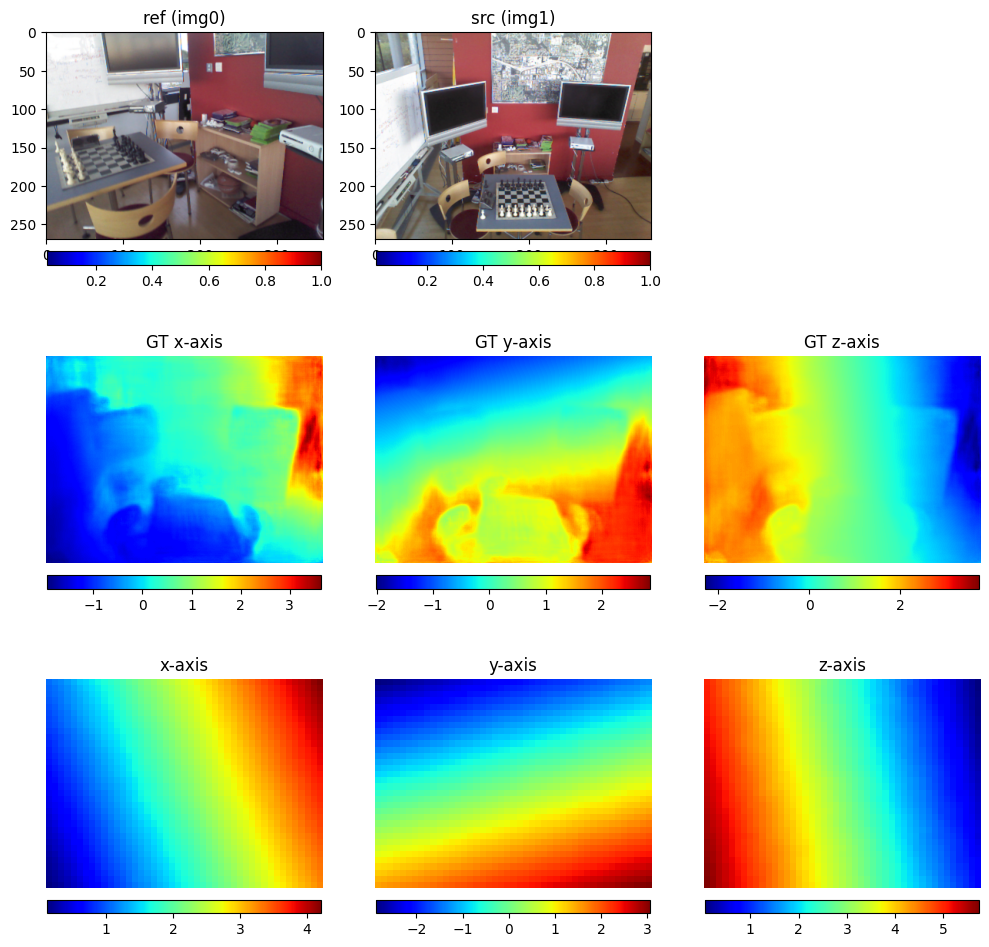

[-1.94046596 -2.01681744 -2.29090429] [3.64581419 2.86122847 3.7199217 ]
[ 0.11713415 -2.8711748   0.05538475] [4.218709 3.058395 5.733926]


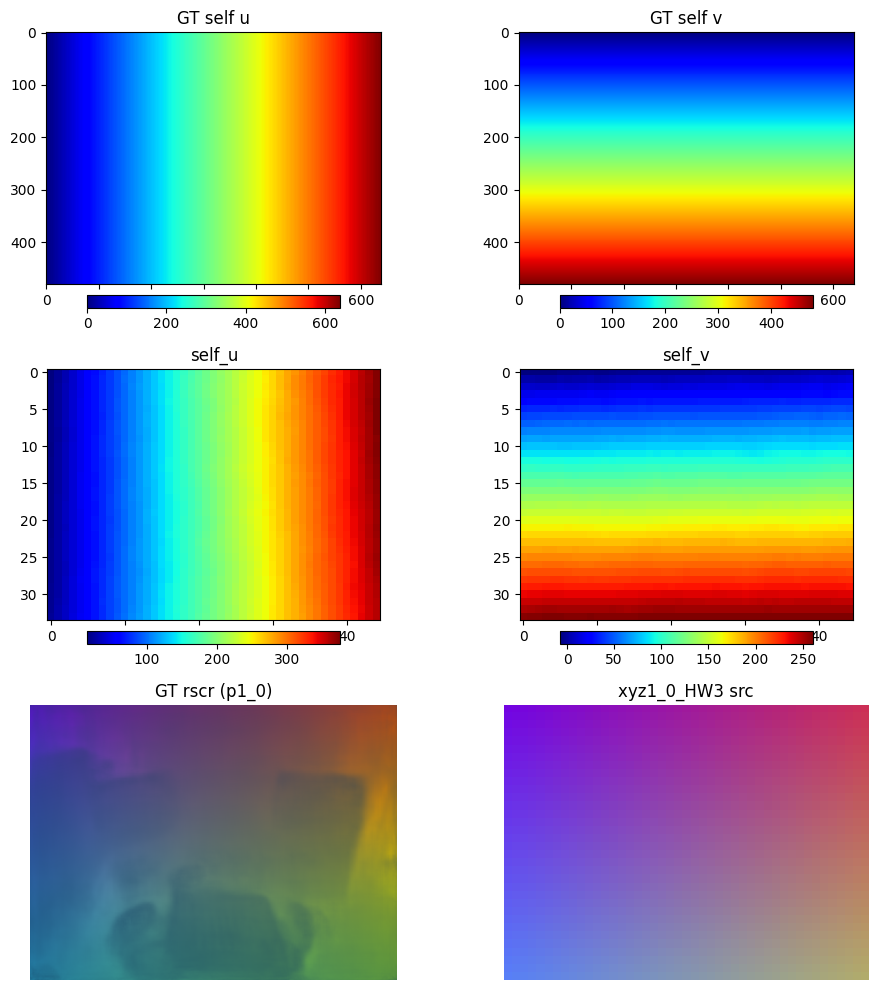

In [21]:
plt.figure(figsize=(10,10))

plt.subplot(3,3,1)
plot_img(img0, title='ref (img0)', axis='on')
plt.subplot(3,3,2)
plot_img(img1, title='src (img1)', axis='on')

plt.subplot(3,3,4)
plot_img(gt_xyz1_0_hw3[..., 0], 'GT x-axis')
plt.subplot(3,3,5)
plot_img(gt_xyz1_0_hw3[..., 1], 'GT y-axis')
plt.subplot(3,3,6)
plot_img(gt_xyz1_0_hw3[..., 2], 'GT z-axis')

plt.subplot(3,3,7)
plot_img(xyz1_0_HW3[..., 0], 'x-axis',
         cmap='jet')

plt.subplot(3,3,8)
plot_img(xyz1_0_HW3[..., 1], 'y-axis',
         cmap='jet')

plt.subplot(3,3,9)
plot_img(xyz1_0_HW3[..., 2], 'z-axis',
         cmap='jet')

plt.tight_layout()
plt.show()


plt.figure(figsize=(10,10))

plt.subplot(3,2,1)
plot_img(gt_uv_hw3[..., 0], title='GT self u', cmap='jet', axis='on')
plt.subplot(3,2,2)
plot_img(gt_uv_hw3[..., 1], title='GT self v', cmap='jet', axis='on')

plt.subplot(3,2,3)
plot_img(uv1_1_HW2[..., 0], 'self_u', cmap='jet', axis='on')

plt.subplot(3,2,4)
plot_img(uv1_1_HW2[..., 1], 'self_v', cmap='jet', axis='on')


rsc_thresh = (np.floor(np.min([np.min(xyz1_0_HW3), np.min(gt_xyz1_0_hw3)])), 
              np.ceil(np.max([np.max(xyz1_0_HW3), np.max(gt_xyz1_0_hw3)])))

plt.subplot(3,2,5)
plot_img(norm_scr(gt_xyz1_0_hw3, *rsc_thresh), 'GT rscr (p1_0)', colorbar=False)
# plot_img(norm_scr(gt_xyz1_1_hw3, -3, 4), 'GT dummy xyz',)

plt.subplot(3,2,6)
plot_img(norm_scr(xyz1_0_HW3, *rsc_thresh), 'xyz1_0_HW3 src', colorbar=False)

plt.tight_layout()
plt.show()

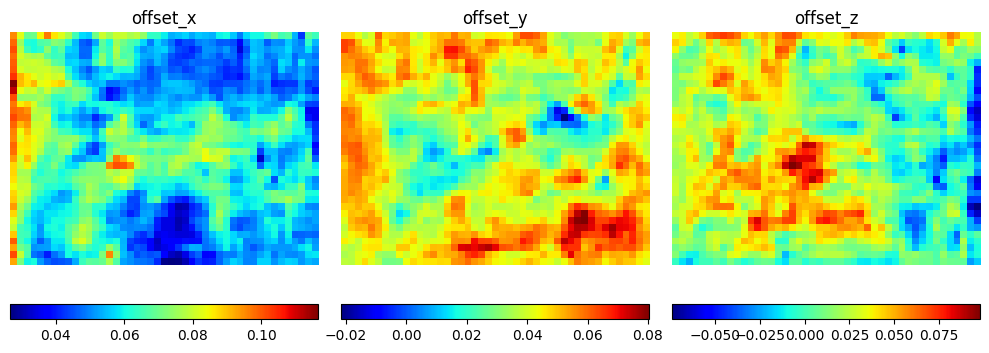

In [22]:
with torch.no_grad():
    offset_B3HW = model.forward(data)
offset_HW3 = offset_B3HW.detach().cpu().numpy()[0].transpose(1,2,0)

plt.figure(figsize=(10,10))
# plt.subplot(2,2,1)
# plot_img(offset_HW3, 'offset')
plt.subplot(1,3,1)
plot_img(offset_HW3[..., 0], 'offset_x', cmap='jet')
plt.subplot(1,3,2)
plot_img(offset_HW3[..., 1], 'offset_y', cmap='jet')
plt.subplot(1,3,3)
plot_img(offset_HW3[..., 2], 'offset_z', cmap='jet')

plt.tight_layout()
plt.show()